### Run DLC for perfect donut scans


### Step 1. Import packages

In [1]:
import numpy as np
import matplotlib.pylab as plt
from pathlib import Path
import sys
import astropy.units as u

plt.ion()
#%matplotlib widget

file_path = '/Users/ashleybaker/Documents/DLC/'
# optional yaml file could feed
config_path = "../dlc_package/configs/gen_config.yaml"

sys.path.insert(0, str(Path(file_path) / "dlc_package"))
from obsdata_utils import cObsLog
from dlc import DifferentialLimbCoupling as dlc_class


### Now initiate the class with our settings

In [ ]:
dlcc = dlc_class(diagnostics_on=False, 
                config=dict(xoffsets = [1], # just run a subset of the offsets for now
                            yoffsets = [0],
                            tt_dyn = [0],
                            theta=0 * u.deg, 
                            vsini=1*u.km/u.s, 
                            R=90000, 
                            bandpass='yJ',
                            diameter=1.0 * u.mas,
                            coupling_map_boundary=600*u.mas,
                            telescope='Keck'))




Loading /Users/ashleybaker/Documents/DLC/dlc_package/data/coupling_maps/staticModel_Keck_yJ_defoc0nmRMS_LO0nmRMS_Fnum3.67_atm0_adc0_nWvls10_PL0.fits
vel slope 0.0475853355 km / s
res vel 3331.0 m / s spec kernel wid 280004.5 m pix / km


### Now step through perfect scans
setting perfect_scan=True in run_jitter will make perfect circles. These can be plotted later to see

In [ ]:
# step through r_in
d_ins = np.array([0, 5, 10, 15, 20, 25, 30, 35, 45, 50, 55])
sims_vels_jitter = np.zeros(len(d_ins))
coupling_effs = np.zeros(len(d_ins))

# run on axis case to get 0
dlcc.run()
sims_vels_jitter[0] = 1000*dlcc.vels[0].value # just save last velocity which is 1 mas off, this is 0 case
coupling_effs[0] = dlcc.coupling_efficiency[0]

# now step through the different scanning ring radii
for i, d_in in enumerate(d_ins[1:], start=1):
    dlcc.run_ttjitter(exp_time=500*u.s, r_in=d_in/2 * u.mas, r_out=40 * u.mas, perfect_scan=True)
    sims_vels_jitter[i] = 1000*dlcc.vels[0].value # just save last velocity which is 1 mas off
    coupling_effs[i] = dlcc.coupling_efficiency[0]


Running x,y position 1.0 mas 0.0 mas
vel -0.0005424540606332667 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0005363562103927681 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0005188555138321521 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00048546935417837666 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.0004363053347414982 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00036637040825745484 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00026976288521967306 km / s
Running x,y position 1.0 mas 0.0 mas
vel -0.00013421817922417852 km / s


### Ok, now plot the result

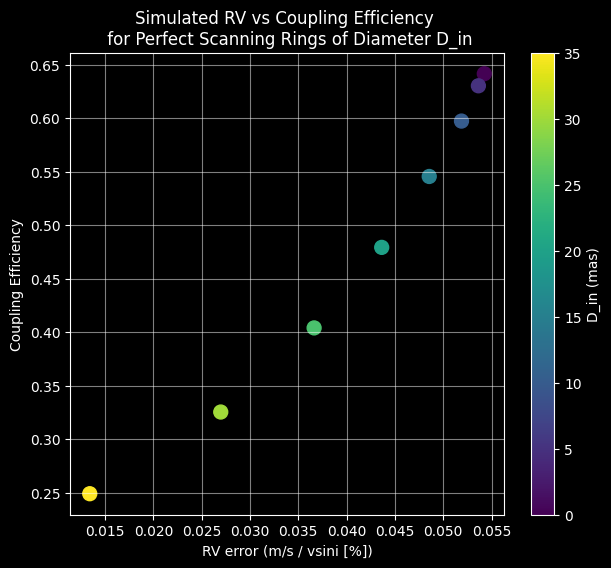

In [4]:
# PLOT
plt.figure(figsize=(7,6))
plt.scatter(100*np.abs(sims_vels_jitter)/1000,coupling_effs,  c=d_ins, s=100, cmap='viridis')
plt.colorbar(label='D_in (mas)')
plt.xlabel('RV error (m/s / vsini [%])')
plt.ylabel('Coupling Efficiency')
plt.title('Simulated RV vs Coupling Efficiency \n for Perfect Scanning Rings of Diameter D_in')
plt.grid(alpha=0.5)
plt.savefig('RV_err_scan_radius.png', dpi=300)  


### Let's see what a scan looks like

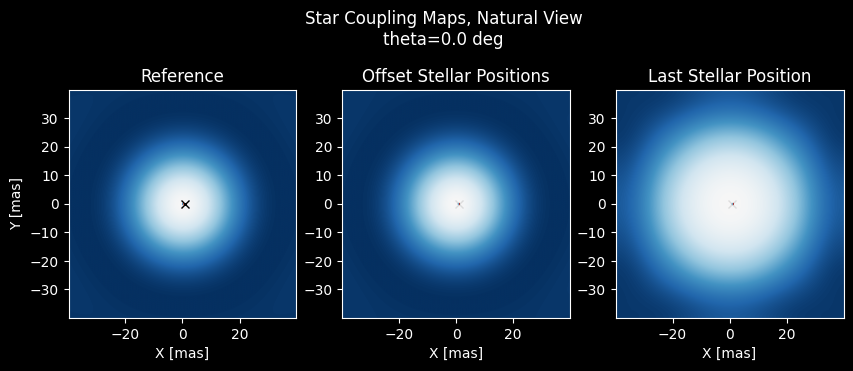

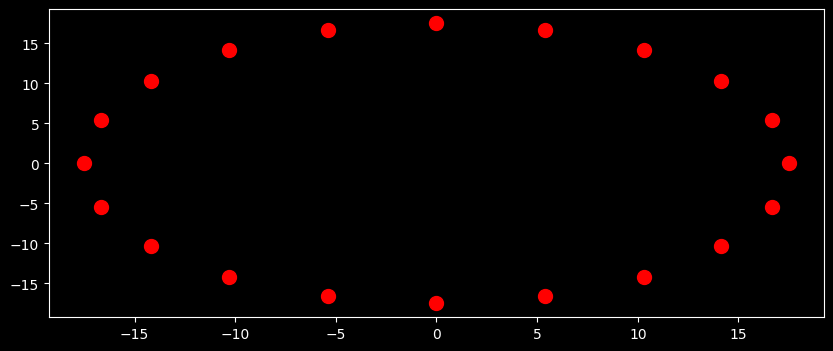

In [5]:
dlcc.plot_star_fiber()
plt.scatter(dlcc.x_jitter[0], dlcc.y_jitter[0], c='red', s=100, label='TT Jitter Pattern')